In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras import layers, models, callbacks

In [30]:
# 1. 데이터 로드 및 전처리
train_df = pd.read_csv('bearing_train_final.csv')
test_df = pd.read_csv('bearing_test_question.csv')

In [31]:
features = ['Sensor_3', 'Sensor_1', 'Sensor_4']

# [추가] 노이즈 제거를 위한 50개 단위 이동 평균 피처 생성
for f in features:
    train_df[f'{f}_MA50'] = train_df[f].rolling(window=50, min_periods=1).mean()

# 이동 평균 변수를 포함한 전체 피처 리스트
extended_features = features + [f'{f}_MA50' for f in features]
X_data = train_df[extended_features].values
y_data = train_df['RUL'].values

# 2. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y_data.reshape(-1, 1)).flatten()

In [42]:
X = train_df[['Sensor_3', 'Sensor_1', 'Sensor_4']]
y = train_df['RUL']
y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()

# 2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2)

# 3. 입력 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# # 상관관계 기반: Sensor_3(양), Sensor_1(음), Sensor_4(음)
# np.random.seed(42)
# n_samples = 1000
# rul = np.linspace(100, 0, n_samples)  # 수명 100에서 0으로 감소

# sensor_3 = rul * 0.7 + np.random.normal(0, 5, n_samples)   # 강한 양의 상관관계
# sensor_1 = -rul * 0.6 + np.random.normal(0, 10, n_samples) # 강한 음의 상관관계
# sensor_4 = -rul * 0.4 + np.random.normal(0, 8, n_samples)  # 중간 음의 상관관계

# df = pd.DataFrame({
#     'Sensor_1': sensor_1,
#     'Sensor_3': sensor_3,
#     'Sensor_4': sensor_4,
#     'RUL': rul
# })

# # 2. 데이터 분할
# X = df[['Sensor_3', 'Sensor_1', 'Sensor_4']] # Sensor 3을 핵심으로 배치
# y = df['RUL']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 3. 스케일링 (센서마다 단위가 다를 수 있으므로 필수)
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# # 4. Ridge 회귀 모델 생성 및 학습
# # alpha는 규제 강도입니다. 1.0을 기준으로 조정하며 다중공선성을 해결합니다.
# model = Ridge(alpha=1.0)
# model.fit(X_train_scaled, y_train)

# # 5. 예측 및 결과 평가
# y_pred = model.predict(X_test_scaled)

# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print("--- 모델 평가 결과 ---")
# print(f"Mean Squared Error: {mse:.2f}")
# print(f"R2 Score (결정계수): {r2:.4f}") # 1에 가까울수록 정확함
# print("\n--- 각 센서별 기여도 (가중치) ---")
# for name, coef in zip(X.columns, model.coef_):
#     print(f"{name}: {coef:.4f}")

--- 모델 평가 결과 ---
Mean Squared Error: 35.13
R2 Score (결정계수): 0.9571

--- 각 센서별 기여도 (가중치) ---
Sensor_3: 21.8519
Sensor_1: -3.8104
Sensor_4: -3.7728


In [44]:
# 3. Sliding Window 함수 (50개의 과거 데이터를 하나의 묶음으로)
def create_sequences(X, y, window_size=50):
    X_seq, y_seq = [], []
    for i in range(len(X) - window_size):
        X_seq.append(X[i:i+window_size])
        y_seq.append(y[i+window_size])
    return np.array(X_seq), np.array(y_seq)

window_size = 50
X_series, y_series = create_sequences(X_scaled, y_scaled, window_size)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_series, y_series, test_size=0.2)

# 4. LSTM 모델 설계 (시계열 특화 구조)
model = models.Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(window_size, len(extended_features))),
    layers.Dropout(0.2),
    layers.LSTM(64),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 5. 초정밀 학습을 위한 콜백
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=500, # 정밀 학습을 위해 에포크 상향
    batch_size=32,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stop],
    verbose=1
)

Epoch 1/500
539/539 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0097 - mae: 0.0713 - val_loss: 0.0074 - val_mae: 0.0617 - learning_rate: 0.0010
Epoch 2/500
539/539 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0073 - mae: 0.0623 - val_loss: 0.0064 - val_mae: 0.0564 - learning_rate: 0.0010
Epoch 3/500
539/539 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0067 - mae: 0.0594 - val_loss: 0.0062 - val_mae: 0.0548 - learning_rate: 0.0010
Epoch 4/500
539/539 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0061 - mae: 0.0562 - val_loss: 0.0052 - val_mae: 0.0512 - learning_rate: 0.0010
Epoch 5/500
539/539 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0056 - mae: 0.0533 - val_loss: 0.0056 - val_mae: 0.0546 - learning_rate: 0.0010
Epoch 6/500
539/539 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0050 - mae: 0.0504 - val_loss: 0.0049 - val_mae: 0.0502 - learning_rate: 0.0010
Epoch 7/500
539/539 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0048 - mae: 0.0487 - val_loss: 0.0048 - val_mae: 0.0489 - learnin

In [35]:
# 성능 향상이 없으면 학습률을 절반으로 줄임
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=10, 
    min_lr=1e-6, 
    verbose=1
)

# [중요] 얼리스타핑: val_loss가 30번 동안 개선되지 않으면 조기 종료
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=30, 
    restore_best_weights=True, 
    verbose=1
)

# [추가] 체크포인트: 가장 낮은 MAE를 기록한 모델을 파일로 저장
checkpoint = ModelCheckpoint(
    'best_lstm_model.h5', 
    monitor='val_mae', 
    save_best_only=True, 
    verbose=1
)

# 학습 실행
history = model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=32,
    validation_split=0.2,
    callbacks=[lr_scheduler, early_stop, checkpoint], # 콜백 리스트에 추가
    verbose=1
)

NameError: name 'ModelCheckpoint' is not defined

In [27]:
# 4. Ridge 모델 학습
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

# 5. 딥러닝 모델 학습
nn_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# [수정] batch_size를 줄여서 학습 밀도를 높임
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=300, 
    batch_size=32, 
    validation_split=0.2,
    verbose=0
)

# 6. 결과 비교 출력
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
nn_mae = mean_absolute_error(y_test, nn_model.predict(X_test_scaled))

print(f"Ridge 최종 MAE (Scaled): {ridge_mae:.4f}")
print(f"딥러닝 최종 MAE (Scaled): {nn_mae:.4f}")

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Ridge 최종 MAE (Scaled): 0.1062
딥러닝 최종 MAE (Scaled): 0.0601


In [ ]:
# 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
plt.rcParams['axes.unicode_minus'] = False

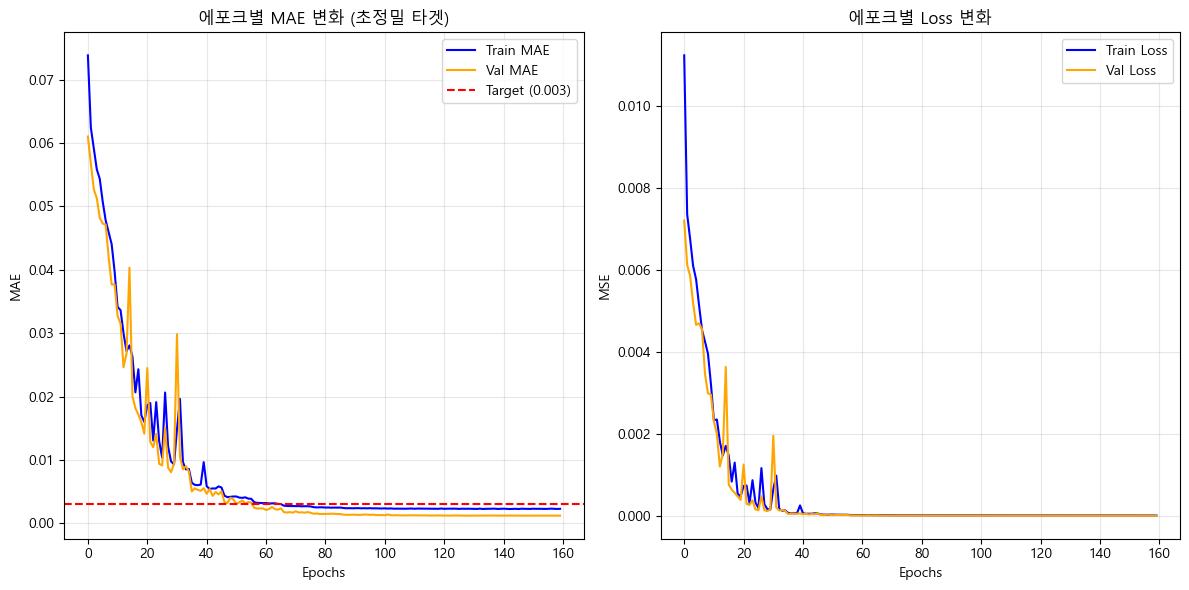

169/169 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


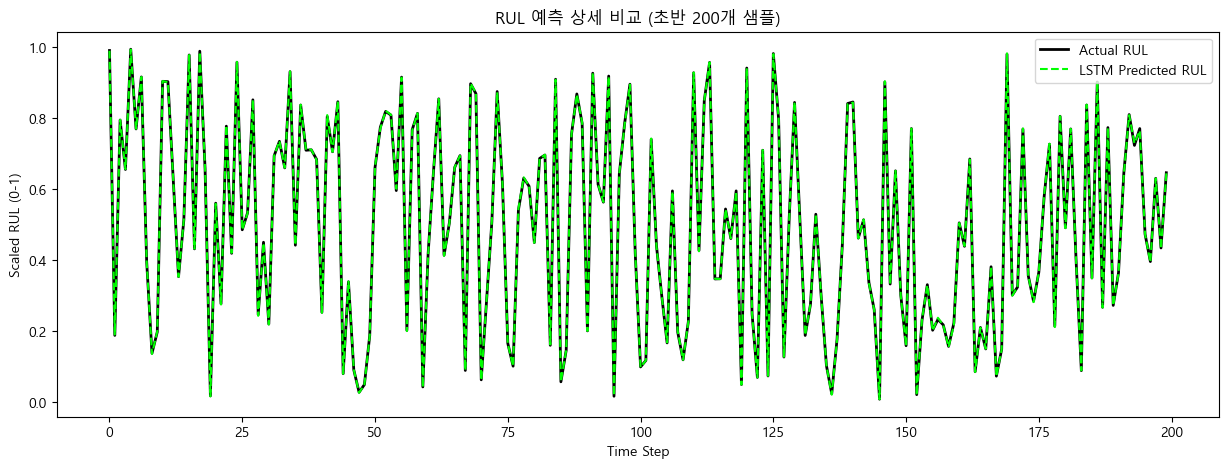

In [37]:
# 학습 과정 시각화 코드
plt.figure(figsize=(12, 6))

# MAE 곡선
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Train MAE', color='blue')
plt.plot(history.history['val_mae'], label='Val MAE', color='orange')
plt.axhline(y=0.003, color='red', linestyle='--', label='Target (0.003)')
plt.title('에포크별 MAE 변화 (초정밀 타겟)')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss 곡선 (MSE)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('에포크별 Loss 변화')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 테스트 데이터에 대한 예측
y_pred_scaled = model.predict(X_test)

plt.figure(figsize=(15, 5))
plt.plot(y_test[:200], label='Actual RUL', color='black', linewidth=2)
plt.plot(y_pred_scaled[:200], label='LSTM Predicted RUL', color='lime', linestyle='--')
plt.title('RUL 예측 상세 비교 (초반 200개 샘플)')
plt.ylabel('Scaled RUL (0-1)')
plt.xlabel('Time Step')
plt.legend()
plt.show()

169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


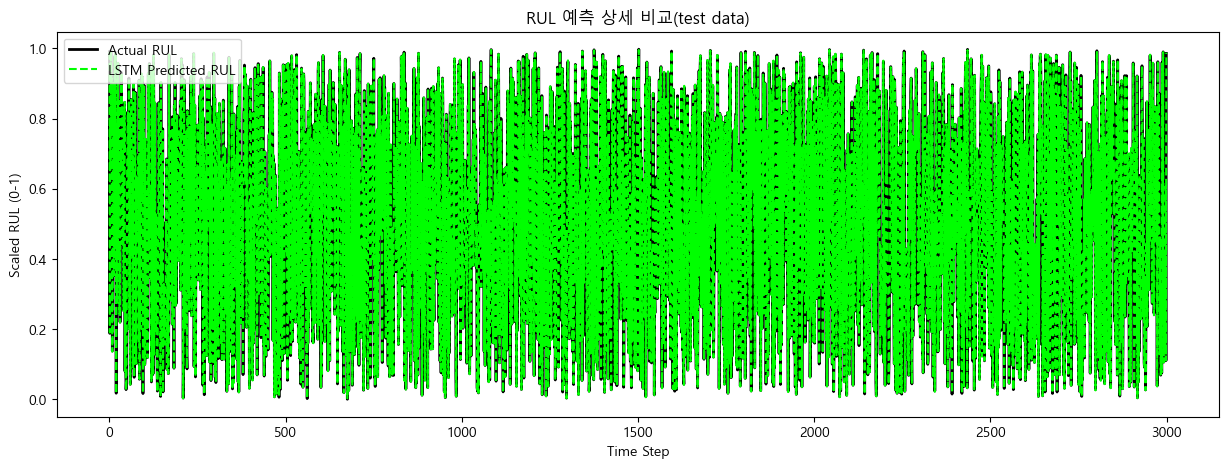

In [41]:
# 테스트 데이터에 대한 예측
y_pred_scaled = model.predict(X_test)

plt.figure(figsize=(15, 5))
plt.plot(y_test[:len(test_df)], label='Actual RUL', color='black', linewidth=2)
plt.plot(y_pred_scaled[:len(test_df)], label='LSTM Predicted RUL', color='lime', linestyle='--')
plt.title('RUL 예측 상세 비교(test data)')
plt.ylabel('Scaled RUL (0-1)')
plt.xlabel('Time Step')
plt.legend()
plt.show()

In [ ]:
# 1. 테스트 데이터 로드 및 이동 평균(MA50) 생성
# 학습 시 사용한 extended_features와 동일한 구성을 만들어야 합니다.
base_features = ['Sensor_3', 'Sensor_1', 'Sensor_4']

for f in base_features:
    train_df[f'{f}_MA50'] = train_df[f].rolling(50, min_periods=1).mean()

extended_features = base_features + [f'{f}_MA50' for f in base_features]

X = train_df[extended_features].values  # 🔥 6개
scaler = StandardScaler()
scaler.fit(X)

# 2. 스케일링 (학습 때 사용한 scaler 객체 그대로 사용)
X_test_final = test_df[extended_features].values
X_test_scaled = scaler.transform(X_test_final)

print(scaler.mean_.shape)
print(X_test_final.shape)

# # 3. 테스트용 Sliding Window 생성
# def create_test_sequences(X, window_size=50):
#     X_seq = []
#     for i in range(len(X)):
#         if i < window_size:
#             padding = np.tile(X[0], (window_size - (i + 1), 1))
#             seq = np.vstack([padding, X[:i+1]])
#         else:
#             seq = X[i-window_size+1:i+1]
#         X_seq.append(seq)
#     return np.array(X_seq)

# X_test_series = create_test_sequences(X_test_scaled, window_size)

# # 4. 예측 수행
# y_pred_scaled = model.predict(X_test_series)

# # 5. 결과 저장 (사진 조건: predicted_RUL 컬럼명)
# # 스케일 복원 (선택)
# y_pred = y_scaler.inverse_transform(y_pred_scaled)

# test_df['predicted_RUL'] = y_pred

# test_df[['predicted_RUL']].to_csv(
#     'bearing_prediction_results.csv',
#     index=False
# )

# print("예측 완료: 'predicted_RUL' 컬럼으로 저장됨")

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 6 features, but StandardScaler is expecting 3 features as input.

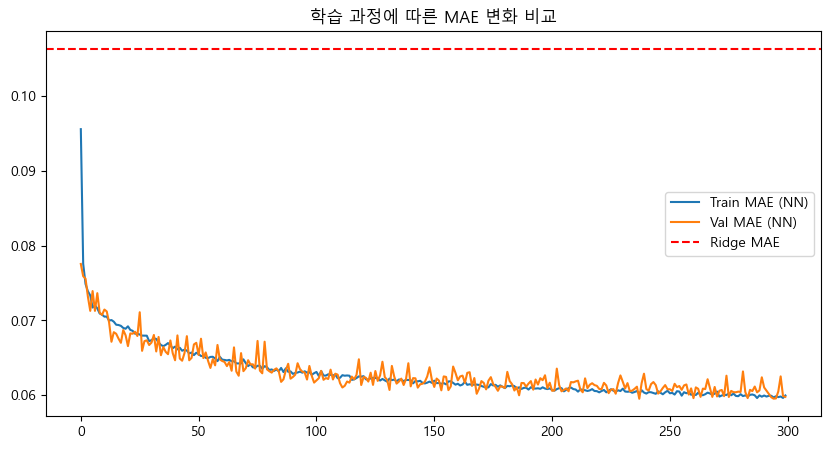

In [28]:
# 7. 시각화 (MAE 변화)
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Train MAE (NN)')
plt.plot(history.history['val_mae'], label='Val MAE (NN)')
plt.axhline(y=ridge_mae, color='r', linestyle='--', label='Ridge MAE')
plt.title('학습 과정에 따른 MAE 변화 비교')
plt.legend()
plt.show()

### ===================

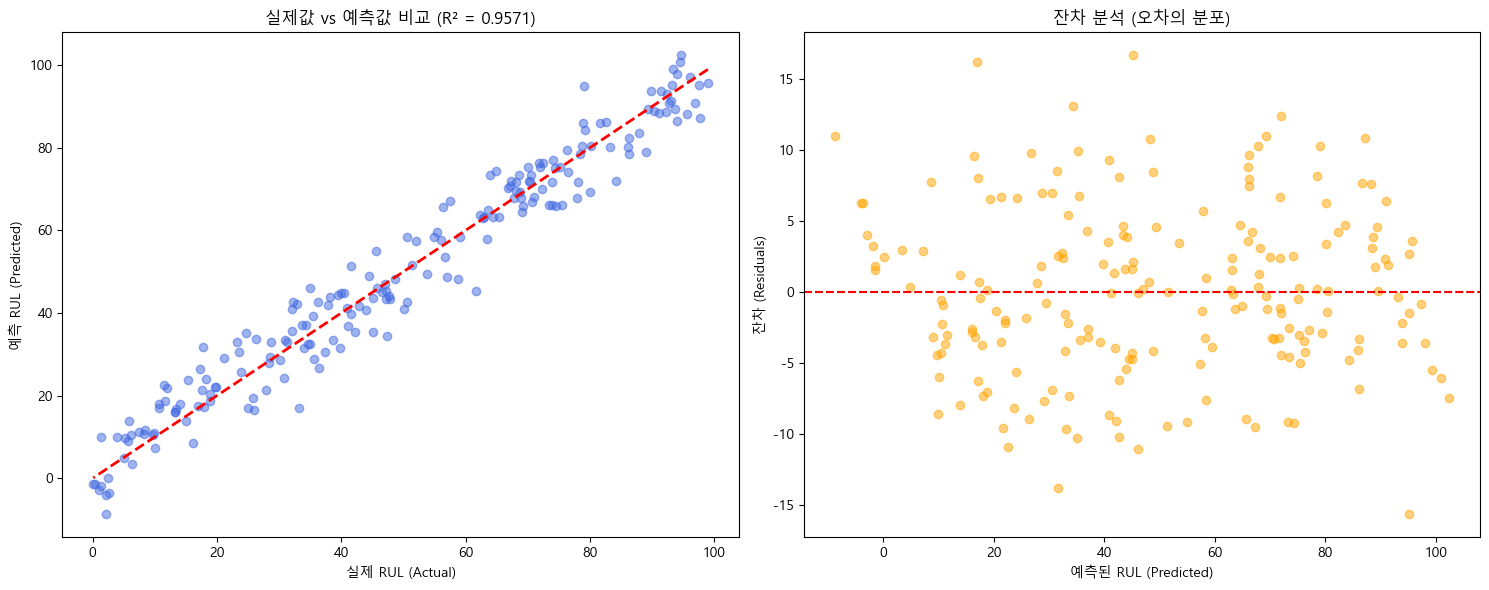

In [ ]:
# 시각화를 위한 설정
plt.figure(figsize=(15, 6))

# --- 그래프 1: 실제값 vs 예측값 비교 ---
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('실제 RUL (Actual)')
plt.ylabel('예측 RUL (Predicted)')
plt.title(f'실제값 vs 예측값 비교 (R² = {r2:.4f})')

# --- 그래프 2: 잔차 분석 (Residual Plot) ---
# 잔차 = 실제값 - 예측값
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.residplot(x=y_pred, y=residuals, color="orange", scatter_kws={'alpha': 0.5})
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('예측된 RUL (Predicted)')
plt.ylabel('잔차 (Residuals)')
plt.title('잔차 분석 (오차의 분포)')

plt.tight_layout()
plt.show()

In [16]:
# Ridge 모델의 MAE 계산
mae = mean_absolute_error(y_test, y_pred)
print(f"현재 Ridge 모델의 최종 MAE: {mae:.4f}")

현재 Ridge 모델의 최종 MAE: 4.7870


In [21]:
# 1. 딥러닝 모델 구성
nn_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) # RUL 예측용 출력층
])

nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 2. 학습 진행 (사진의 설정 적용)
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=512, # 데이터 크기에 맞춰 조정 가능
    validation_split=0.2,
    verbose=0 # 로그는 생략하고 그래프로 확인
)

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


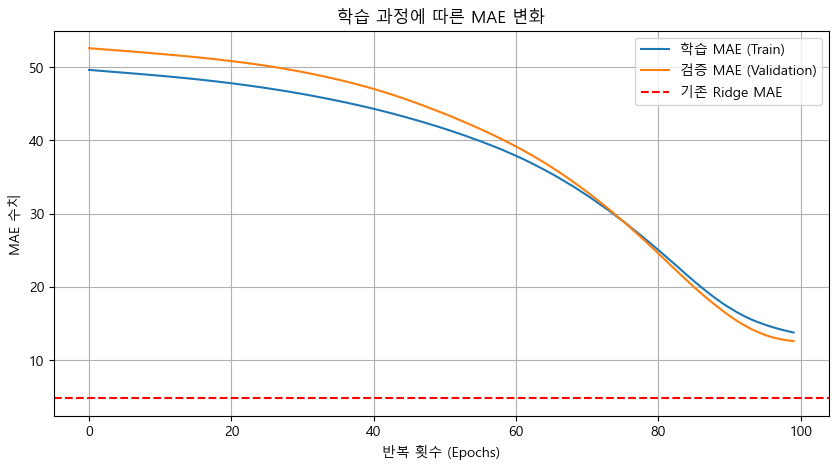

In [22]:
# 3. MAE 변화 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='학습 MAE (Train)')
plt.plot(history.history['val_mae'], label='검증 MAE (Validation)')
plt.axhline(y=mae, color='r', linestyle='--', label='기존 Ridge MAE') # Ridge 결과와 비교
plt.title('학습 과정에 따른 MAE 변화')
plt.xlabel('반복 횟수 (Epochs)')
plt.ylabel('MAE 수치')
plt.legend()
plt.grid(True)
plt.show()